### Week 5 Task — Model Comparison

##### Train multiple models:
- Random Forest
- SVM
- KNN
- Compare results.
##### Table comparing:
- | Model | Accuracy | Precision | Recall |
- Explain which model performs best.

### 1.Importing Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### Load The Dataset

In [3]:
df = pd.read_csv('Titanic.csv')
print("Shape:",df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Summary

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Finding Missing values

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observations

- Age has a significant number of missing values
- cabin is missing for most passengers, so we will drop it
- Name, Ticket, PassengerId are text fields that not used for prediction so we can remove it

### EDA - Data Preprocessing

In [7]:
### Filling missng values with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode Categorical variables
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])

df = pd.get_dummies(df,columns=['Embarked'],drop_first=True)

# Dropping the column that not used in model training
df = df.drop(columns=['Name','Cabin','Ticket','PassengerId'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


### Split the dataset (Feature and Target Variable)

In [8]:
X = df.drop(columns=['Survived'])
y = df['Survived']

### Train-Test split

In [9]:
# using 80% data for training and 20% for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 8)
Testing set size: (179, 8)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


### Model 1: Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
Rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
Rf_model.fit(X_train,y_train)

Rf_pred = Rf_model.predict(X_test)

Rf_result = {
    'Accuracy':accuracy_score(y_test,Rf_pred),
    'Precision':precision_score(y_test,Rf_pred),
    'Recall':recall_score(y_test,Rf_pred),
    'F1-Score':f1_score(y_test,Rf_pred)
}

### Model2: SVM(Support Vector Machine)

In [12]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf',random_state=42)
svm.fit(X_train_scaled,y_train)
svm_pred = svm.predict(X_test_scaled)

Svm_result = {
    'Accuracy':accuracy_score(y_test,svm_pred),
    'Precision':precision_score(y_test,svm_pred),
    'Recall':recall_score(y_test,svm_pred),
    'F1-Score':f1_score(y_test,svm_pred)
}

### Model 3: KNN(K-Nearest Neighbour)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

Knn = KNeighborsClassifier(n_neighbors=5)
Knn.fit(X_train_scaled,y_train)
knn_pred = Knn.predict(X_test_scaled)

Knn_result = {
    'Accuracy':accuracy_score(y_test,knn_pred),
    'Precision':precision_score(y_test,knn_pred),
    'Recall':recall_score(y_test,knn_pred),
    'F1-Score':f1_score(y_test,knn_pred)
}


### Comparison of Each Model

In [14]:
comparison_df = pd.DataFrame({
    'Random Forest':Rf_result,
    'SVM':Svm_result,
    'KNN':Knn_result
}).T.round(4)

comparison_df

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.8156,0.7903,0.7101,0.7481
SVM,0.8101,0.8431,0.6232,0.7167
KNN,0.8156,0.8000,0.6957,0.7442


### Data Visualization For Model Comparison

In [15]:
comparison_table = comparison_df[['Accuracy','Precision','Recall']]
comparison_table

,Accuracy,Precision,Recall
Random Forest,0.8156,0.7903,0.7101
SVM,0.8101,0.8431,0.6232
KNN,0.8156,0.8000,0.6957


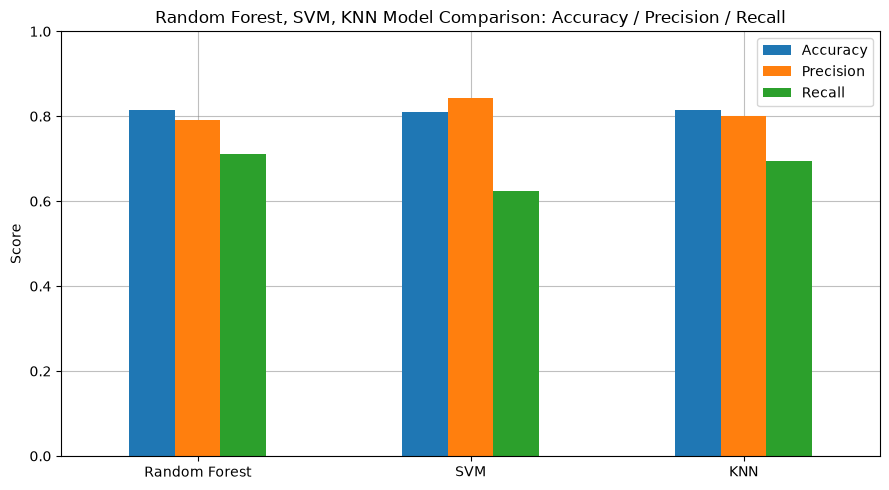

In [ ]:
ax = comparison_table.plot(kind='bar', figsize=(9, 5))

ax.set_title('Random Forest, SVM, KNN Model Comparison: Accuracy / Precision / Recall')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.legend(loc='upper right')

# Grid lines inside chart (both axes)
ax.grid(
    which='major',
    axis='both',   
    linestyle='-',
    alpha=0.5,
    color='gray'
)

# Ensure grid is behind the bars
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Which Model perform's Better

- **Random Forest** and **KNN** achieved the joint highest accuracy (0.8156), but Random Forest has the higher recall (0.7101 vs. 0.6957). This means Random Forest identifies a larger proportion of the actual survivors while maintaining strong overall performance.

- **SVM** achieved the highest precision (0.8431), meaning that when it predicts a passenger survived, it is correct more often than the other models. However, it has the lowest recall (0.6232), indicating that it misses a larger number of actual survivors. This reflects the typical precision-recall trade-off, where the model is more conservative in making positive predictions.

- **KNN** matches Random Forest in accuracy (0.8156) and has slightly higher precision (0.8000 vs. 0.7903), but its recall (0.6957) is lower than Random Forest. As a distance-based algorithm, KNN can perform well when similar passengers are clustered together, but it may be more sensitive to feature noise and data distribution than Random Forest.